# Data Preprocessing Lab
    ## Integrate, Clean, Reduce, and Transform

    This lab follows the lecture flow:

    **Raw data → Integration → Cleaning → Reduction → Transformation → Analysis-ready data**

    You will work with several small datasets so that each idea is easy to see:

    - a **Titanic-style passenger dataset** for joins and cleaning,
    - the built-in **Wine dataset** for correlation, sampling, scaling, and PCA,
    - the built-in **Iris dataset** for encoding and transformation,
    - a small **country incidents table** for tidy-data reshaping,
    - a small **customer dataset** for a final challenge.

    No internet connection and no external CSV files are required.


> **Student edition:** complete the questions and `TODO` code cells. Do not look for an answer key in this notebook.

## Learning objectives

By the end of this lab, you should be able to:

1. Inspect a dataset before changing it.
2. Combine tables using inner, left, right, and outer joins.
3. Detect and handle missing, invalid, inconsistent, and duplicate data.
4. Explain why there is no single best way to handle missing values.
5. Reduce data using sampling, correlation analysis, and PCA.
6. Transform data using tidy reshaping, one-hot encoding, min-max scaling, z-score standardization, and log transformation.
7. Explain *why* a preprocessing step is appropriate, not just write the code.

## 0. Setup

Run this cell first. We use only common Python data-science packages.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.datasets import load_wine, load_iris
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

RANDOM_STATE = 42
print("Setup complete.")

Setup complete.


# 1. Start by understanding the data

Before cleaning anything, ask:

- What does one row represent?
- What does each column mean?
- How many rows and columns are there?
- Which columns are numeric or categorical?
- Are values missing?
- Are there impossible values or duplicates?

This is a small form of **exploratory data analysis (EDA)**.

In [2]:
passenger_features = pd.DataFrame({
    "passenger_id": [1,2,3,4,5,6,7,8,9,10,11,12],
    "name": [
        "Amina Ali","Ben Carter","Carlos Diaz","Dina Evans",
        "Evan Ford","Fatima Gray","George Hill","Hana Ibrahim",
        "Isaac Jones","Julia King","Khalid Lewis","Lina Moore"
    ],
    "sex": ["female","male","male","F","male","Female","M","female","male","F","male","female"],
    "age": [29, 41, 22, np.nan, 35, 31, 52, np.nan, 18, 150, 27, 44],
    "fare": [72.5, 8.1, 13.0, 26.0, 80.0, 7.9, -5.0, 53.1, 9.5, 30.0, 11.0, 15.5],
    "embarked": ["Southampton","S","Cherbourg","C","S","Queenstown","Q",None,"S","Southampton","C","S"]
})

passenger_outcomes = pd.DataFrame({
    "passenger_id": [1,2,3,4,5,6,7,8,9,10,13],
    "survived":     [1,0,1,1,0,1,0,1,0,0,1],
    "cabin_group":  ["A","B","C","C","B","D","E","A","F","B","G"]
})

print("Passenger features")
display(passenger_features)

print("\nPassenger outcomes")
display(passenger_outcomes)

Passenger features


,passenger_id,name,sex,age,fare,embarked
0,1,Amina Ali,female,29.0,72.5,Southampton
1,2,Ben Carter,male,41.0,8.1,S
2,3,Carlos Diaz,male,22.0,13.0,Cherbourg
3,4,Dina Evans,F,NaN,26.0,C
4,5,Evan Ford,male,35.0,80.0,S
5,6,Fatima Gray,Female,31.0,7.9,Queenstown
6,7,George Hill,M,52.0,-5.0,Q
7,8,Hana Ibrahim,female,NaN,53.1,None
8,9,Isaac Jones,male,18.0,9.5,S
9,10,Julia King,F,150.0,30.0,Southampton



Passenger outcomes


,passenger_id,survived,cabin_group
0,1,1,A
1,2,0,B
2,3,1,C
3,4,1,C
4,5,0,B
5,6,1,D
6,7,0,E
7,8,1,A
8,9,0,F
9,10,0,B


### Question 1

Without changing the data yet, list **four possible data-quality concerns** you notice in `passenger_features`.

**Your answer:**

1.  NaN's are present
2.  Different formats of sex are used
3.  There are negative fares
4. There is a passenger that has a value of None in the embarked column

In [3]:
print("Shape:", passenger_features.shape)
print("\nData types:")
print(passenger_features.dtypes)

print("\nMissing values:")
print(passenger_features.isna().sum())

print("\nNumeric summary:")
display(passenger_features.select_dtypes(include=np.number).describe())

Shape: (12, 6)

Data types:
passenger_id      int64
name             object
sex              object
age             float64
fare            float64
embarked         object
dtype: object

Missing values:
passenger_id    0
name            0
sex             0
age             2
fare            0
embarked        1
dtype: int64

Numeric summary:


,passenger_id,age,fare
count,12.000000,10.000000,12.000000
mean,6.500000,44.900000,26.800000
std,3.605551,38.333188,27.313833
min,1.000000,18.000000,-5.000000
25%,3.750000,27.500000,9.150000
50%,6.500000,33.000000,14.250000
75%,9.250000,43.250000,35.775000
max,12.000000,150.000000,80.000000


# 2. Data Integration

**Data integration** combines information from multiple sources.

The key idea for joins:

- **Inner join:** keep only matching keys.
- **Left join:** keep every row from the left table.
- **Right join:** keep every row from the right table.
- **Outer join:** keep every key from both tables.

Here, the common key is `passenger_id`.

In [4]:
inner_join = pd.merge(
    passenger_features,
    passenger_outcomes,
    on="passenger_id",
    how="inner"
)

left_join = pd.merge(
    passenger_features,
    passenger_outcomes,
    on="passenger_id",
    how="left"
)

print("Feature rows:", len(passenger_features))
print("Outcome rows:", len(passenger_outcomes))
print("Inner rows:", len(inner_join))
print("Left rows:", len(left_join))

display(inner_join.head())

Feature rows: 12
Outcome rows: 11
Inner rows: 10
Left rows: 12


,passenger_id,name,sex,age,fare,embarked,survived,cabin_group
0,1,Amina Ali,female,29.0,72.5,Southampton,1,A
1,2,Ben Carter,male,41.0,8.1,S,0,B
2,3,Carlos Diaz,male,22.0,13.0,Cherbourg,1,C
3,4,Dina Evans,F,NaN,26.0,C,1,C
4,5,Evan Ford,male,35.0,80.0,S,0,B


### Question 2

Why did the inner join produce fewer rows than the feature table?

**Your answer:**
Because we only joined rows where the passenger id was present in both tables.

### Exercise 1: Outer join with an audit column

Create an **outer join** using `indicator=True`.

Then:

1. Display the result.
2. Count `_merge`.
3. Identify IDs that appear only in the feature table.
4. Identify IDs that appear only in the outcome table.

In [5]:
# Create an outer join with indicator=True

outer_join = pd.merge(passenger_features, passenger_outcomes, how="outer", indicator=True)

display(outer_join)


# Count the values in the _merge column

print(outer_join._merge.value_counts())

# Find passenger IDs found only on the left

display(outer_join[outer_join._merge == "left_only"])

# Find passenger IDs found only on the right

display(outer_join[outer_join._merge == "right_only"])


,passenger_id,name,sex,age,fare,embarked,survived,cabin_group,_merge
0,1,Amina Ali,female,29.0,72.5,Southampton,1.0,A,both
1,2,Ben Carter,male,41.0,8.1,S,0.0,B,both
2,3,Carlos Diaz,male,22.0,13.0,Cherbourg,1.0,C,both
3,4,Dina Evans,F,NaN,26.0,C,1.0,C,both
4,5,Evan Ford,male,35.0,80.0,S,0.0,B,both
5,6,Fatima Gray,Female,31.0,7.9,Queenstown,1.0,D,both
6,7,George Hill,M,52.0,-5.0,Q,0.0,E,both
7,8,Hana Ibrahim,female,NaN,53.1,None,1.0,A,both
8,9,Isaac Jones,male,18.0,9.5,S,0.0,F,both
9,10,Julia King,F,150.0,30.0,Southampton,0.0,B,both


_merge
both          10
left_only      2
right_only     1
Name: count, dtype: int64


,passenger_id,name,sex,age,fare,embarked,survived,cabin_group,_merge
10,11,Khalid Lewis,male,27.0,11.0,C,NaN,NaN,left_only
11,12,Lina Moore,female,44.0,15.5,S,NaN,NaN,left_only


,passenger_id,name,sex,age,fare,embarked,survived,cabin_group,_merge
12,13,NaN,NaN,NaN,NaN,NaN,1.0,G,right_only


### Quick prediction

Before running the next cell, predict the row counts for each join.

In [6]:
for join_type in ["inner", "left", "right", "outer"]:
    result = pd.merge(
        passenger_features,
        passenger_outcomes,
        on="passenger_id",
        how=join_type
    )
    print(f"{join_type:>5} join -> {len(result)} rows")

inner join -> 10 rows
 left join -> 12 rows
right join -> 11 rows
outer join -> 13 rows


# 3. Data Cleaning

Real-world data may be:

- **Incomplete:** values are missing.
- **Inaccurate/noisy:** values are wrong or suspicious.
- **Inconsistent:** the same idea is represented in different ways.
- **Duplicated:** the same record appears more than once.

We will intentionally create a duplicate so that all four problems are visible.

In [7]:
dirty = passenger_features.copy()

# Add one duplicate record on purpose.
dirty = pd.concat(
    [dirty, dirty.loc[dirty["passenger_id"] == 5]],
    ignore_index=True
)

display(dirty)

,passenger_id,name,sex,age,fare,embarked
0,1,Amina Ali,female,29.0,72.5,Southampton
1,2,Ben Carter,male,41.0,8.1,S
2,3,Carlos Diaz,male,22.0,13.0,Cherbourg
3,4,Dina Evans,F,NaN,26.0,C
4,5,Evan Ford,male,35.0,80.0,S
5,6,Fatima Gray,Female,31.0,7.9,Queenstown
6,7,George Hill,M,52.0,-5.0,Q
7,8,Hana Ibrahim,female,NaN,53.1,None
8,9,Isaac Jones,male,18.0,9.5,S
9,10,Julia King,F,150.0,30.0,Southampton


In [8]:
print("Missing values:")
print(dirty.isna().sum())

print("\nDuplicate passenger IDs:")
display(dirty[dirty.duplicated(subset="passenger_id", keep=False)])

print("\nSex categories:")
print(dirty["sex"].value_counts(dropna=False))

print("\nEmbarked categories:")
print(dirty["embarked"].value_counts(dropna=False))

print("\nSuspicious ages:")
display(dirty[(dirty["age"] < 0) | (dirty["age"] > 100)])

print("\nSuspicious fares:")
display(dirty[dirty["fare"] < 0])

Missing values:
passenger_id    0
name            0
sex             0
age             2
fare            0
embarked        1
dtype: int64

Duplicate passenger IDs:


,passenger_id,name,sex,age,fare,embarked
4,5,Evan Ford,male,35.0,80.0,S
12,5,Evan Ford,male,35.0,80.0,S



Sex categories:
sex
male      6
female    3
F         2
Female    1
M         1
Name: count, dtype: int64

Embarked categories:
embarked
S              5
Southampton    2
C              2
Cherbourg      1
Queenstown     1
Q              1
None           1
Name: count, dtype: int64

Suspicious ages:


,passenger_id,name,sex,age,fare,embarked
9,10,Julia King,F,150.0,30.0,Southampton



Suspicious fares:


,passenger_id,name,sex,age,fare,embarked
6,7,George Hill,M,52.0,-5.0,Q


## 3.1 Clean inconsistent categories

A simple rule can map several representations to one standard representation.

In [9]:
sex_map = {
    "F": "female",
    "Female": "female",
    "female": "female",
    "M": "male",
    "Male": "male",
    "male": "male"
}

embarked_map = {
    "S": "Southampton",
    "Southampton": "Southampton",
    "C": "Cherbourg",
    "Cherbourg": "Cherbourg",
    "Q": "Queenstown",
    "Queenstown": "Queenstown"
}

cleaned = dirty.copy()
cleaned["sex"] = cleaned["sex"].map(sex_map)
cleaned["embarked"] = cleaned["embarked"].map(embarked_map)

print(cleaned["sex"].value_counts(dropna=False))
print()
print(cleaned["embarked"].value_counts(dropna=False))

sex
male      7
female    6
Name: count, dtype: int64

embarked
Southampton    7
Cherbourg      3
Queenstown     2
NaN            1
Name: count, dtype: int64


## 3.2 Invalid values

If a value violates a rule we trust, do not quietly pretend it is correct.

Here we will mark:

- age > 100 as missing,
- fare < 0 as missing.

This is a teaching rule for this dataset, not a universal rule for all datasets.

In [10]:
cleaned.loc[cleaned["age"] > 100, "age"] = np.nan
cleaned.loc[cleaned["fare"] < 0, "fare"] = np.nan

print("Missing values after invalid values were replaced by NaN:")
print(cleaned.isna().sum())

Missing values after invalid values were replaced by NaN:
passenger_id    0
name            0
sex             0
age             3
fare            1
embarked        1
dtype: int64


## 3.3 Duplicates

In [11]:
print("Rows before:", len(cleaned))

cleaned = cleaned.drop_duplicates(subset="passenger_id", keep="first").copy()

print("Rows after :", len(cleaned))

Rows before: 13
Rows after : 12


## 3.4 Missing values: there is no universal fix

Common choices include:

- leave missing values as missing,
- remove rows,
- remove a column,
- fill with mean/median/mode,
- predict/impute values using a model,
- use an algorithm that can natively handle missing values.

The correct choice depends on **why the value is missing, how much is missing, and how the data will be used**.

### Question 3

Why is replacing a missing value with `0` often dangerous?

**Your answer:**

It can skew the results of the ml

In [12]:
print("Age values before imputation:")
print(cleaned["age"].tolist())

print("\nMean age  :", cleaned["age"].mean())
print("Median age:", cleaned["age"].median())

Age values before imputation:
[29.0, 41.0, 22.0, nan, 35.0, 31.0, 52.0, nan, 18.0, nan, 27.0, 44.0]

Mean age  : 33.22222222222222
Median age: 31.0


### Exercise 2: Impute missing values

Make a copy named `cleaned_imputed`.

1. Fill missing `age` with the **median**.
2. Fill missing `fare` with the **median**.
3. Fill missing `embarked` with the **mode**.
4. Verify that those three columns no longer contain missing values.

In [13]:
cleaned_imputed = cleaned.copy()
# 1. Fill missing age with the median

cleaned_imputed["age"].fillna(cleaned_imputed["age"].median(), inplace=True)

# 2. Fill missing fare with the median

cleaned_imputed["fare"].fillna(cleaned_imputed["fare"].median(), inplace=True)


# 3. Fill missing embarked with the mode

cleaned_imputed["embarked"].fillna(cleaned_imputed["embarked"].mode()[0], inplace=True)


# 4. Verify missing values
display(cleaned_imputed.isna().sum())


/tmp/ipykernel_843/1658788118.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cleaned_imputed["age"].fillna(cleaned_imputed["age"].median(), inplace=True)
/tmp/ipykernel_843/1658788118.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

,0
passenger_id,0
name,0
sex,0
age,0
fare,0
embarked,0


## 3.5 Noisy data: binning and smoothing

Using the lecture example:

`4, 8, 9, 15, 21, 21, 24, 25, 26, 28, 29, 34`

We divide the sorted values into three **equal-depth bins** with four values each.

In [14]:
prices = np.array([4, 8, 9, 15, 21, 21, 24, 25, 26, 28, 29, 34])

bins = np.array_split(prices, 3)

for i, b in enumerate(bins, start=1):
    print(f"Bin {i}: {b.tolist()}  mean={b.mean():.2f}")

Bin 1: [4, 8, 9, 15]  mean=9.00
Bin 2: [21, 21, 24, 25]  mean=22.75
Bin 3: [26, 28, 29, 34]  mean=29.25


### Exercise 3: Smooth by bin means

Replace every value in each bin by that bin's mean.

In [18]:
# TODO: create smoothed_by_mean
# Hint: use b.mean() for each bin.

smoothed_by_mean = np.array([])
for b in bins:
    smoothed_by_mean = np.concatenate((smoothed_by_mean, np.full(len(b), b.mean())))

print(smoothed_by_mean.tolist())

[9.0, 9.0, 9.0, 9.0, 22.75, 22.75, 22.75, 22.75, 29.25, 29.25, 29.25, 29.25]


# 4. Data Reduction

The goal is to use a **smaller representation** while preserving useful information.

We will study:

1. removing redundant variables using correlation,
2. sampling fewer rows,
3. PCA for dimensionality reduction.

In [19]:
wine = load_wine(as_frame=True)
wine_df = wine.frame.copy()

print("Wine dataset shape:", wine_df.shape)
print("Target classes:", wine.target_names)
display(wine_df.head())

Wine dataset shape: (178, 14)
Target classes: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 4.1 Correlation

Pearson correlation ranges from `-1` to `1`.

- near `+1`: strong positive linear relationship,
- near `-1`: strong negative linear relationship,
- near `0`: weak/no **linear** relationship.

**Important clarification:** zero Pearson correlation does **not** automatically mean two variables are independent.

In [20]:
feature_cols = wine.feature_names
corr = wine_df[feature_cols].corr()

# Show the strongest absolute correlations, excluding self-correlation.
pairs = (
    corr.abs()
        .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(ascending=False)
)

print("Top 8 absolute correlations:")
print(pairs.head(8))

Top 8 absolute correlations:
total_phenols  flavanoids                      0.864564
flavanoids     od280/od315_of_diluted_wines    0.787194
total_phenols  od280/od315_of_diluted_wines    0.699949
flavanoids     proanthocyanins                 0.652692
alcohol        proline                         0.643720
total_phenols  proanthocyanins                 0.612413
hue            od280/od315_of_diluted_wines    0.565468
malic_acid     hue                             0.561296
dtype: float64


### Question 4

If two features have correlation `0.95`, should we automatically delete one of them?

**Your answer:**

No, it should be a decision made for a specific purpose.

## 4.2 Sampling

Sampling reduces the **number of rows**.

In [21]:
random_sample = wine_df.sample(n=20, random_state=RANDOM_STATE)

print("Full rows   :", len(wine_df))
print("Sample rows :", len(random_sample))
display(random_sample.head())

Full rows   : 178
Sample rows : 20


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
19,13.64,3.10,2.56,15.2,116.0,2.70,3.03,0.17,1.66,5.10,0.96,3.36,845.0,0
45,14.21,4.04,2.44,18.9,111.0,2.85,2.65,0.30,1.25,5.24,0.87,3.33,1080.0,0
140,12.93,2.81,2.70,21.0,96.0,1.54,0.50,0.53,0.75,4.60,0.77,2.31,600.0,2
30,13.73,1.50,2.70,22.5,101.0,3.00,3.25,0.29,2.38,5.70,1.19,2.71,1285.0,0
67,12.37,1.17,1.92,19.6,78.0,2.11,2.00,0.27,1.04,4.68,1.12,3.48,510.0,1


### Exercise 4: Stratified sampling

Take approximately **20% from each wine class**.

Then compare class proportions in the full dataset and the sample.

In [25]:
# TODO: take a 20% sample from each target group
# Hint:
# wine_df.groupby("target", group_keys=False).sample(...)
stratified_sample = wine_df.groupby("target", group_keys=False).sample(frac=0.2, random_state=RANDOM_STATE)

display(wine_df["target"].value_counts(normalize=True))

display(stratified_sample["target"].value_counts(normalize=True))

,proportion
target,
1,0.398876
0,0.331461
2,0.269663


,proportion
target,
1,0.388889
0,0.333333
2,0.277778


## 4.3 PCA

PCA transforms many numeric features into a smaller number of new features called **principal components**.

Because PCA is sensitive to feature scale, we standardize the features first.

In [26]:
X_wine = wine_df[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_wine)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Original number of features:", X_wine.shape[1])
print("Reduced number of features :", X_pca.shape[1])
print("Explained variance ratio   :", pca.explained_variance_ratio_)
print("Total explained variance   :", pca.explained_variance_ratio_.sum())

Original number of features: 13
Reduced number of features : 2
Explained variance ratio   : [0.36198848 0.1920749 ]
Total explained variance   : 0.5540633835693527


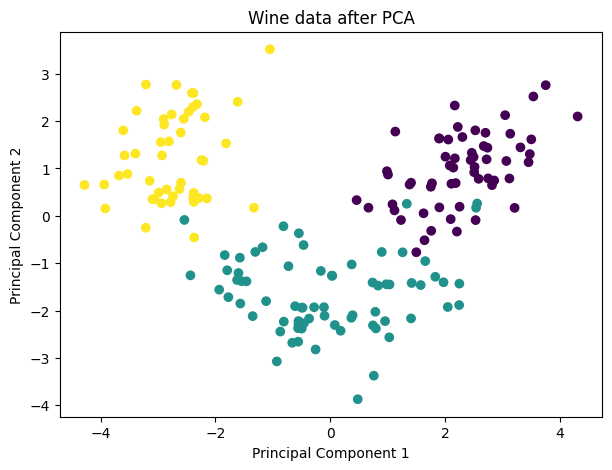

In [27]:
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=wine_df["target"])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Wine data after PCA")
plt.show()

### Question 5

Why do we usually standardize variables before PCA when the variables have very different units or scales?

**Your answer:**

Standardization is usually performed to prevent features with larger ranges from dominating the principal components

# 5. Data Transformation

Transformation changes how values or the table structure are represented.

We will practice:

- tidy reshaping,
- one-hot encoding,
- min-max normalization,
- z-score standardization,
- log transformation.

## 5.1 Tidy data

A common tidy-data idea is:

- each observation has its own row,
- each variable has its own column,
- each value has its own cell.

In [28]:
incidents_wide = pd.DataFrame({
    "Country": ["UK", "France", "China"],
    "Date": ["22/04/2020", "22/04/2020", "22/04/2020"],
    "Incidents": [18, 11, 21],
    "Resolutions": [10, 9, 18]
})

display(incidents_wide)

,Country,Date,Incidents,Resolutions
0,UK,22/04/2020,18,10
1,France,22/04/2020,11,9
2,China,22/04/2020,21,18


### Exercise 5: Reshape wide → long

Use `pd.melt()` to create columns:

`Country`, `Date`, `Type`, `Count`

where `Type` contains `Incidents` or `Resolutions`.

In [29]:
# TODO: reshape incidents_wide with pd.melt()
incidents_long = pd.melt(
    incidents_wide,
    id_vars=["Country", "Date"],
    value_vars=["Incidents", "Resolutions"],
    var_name="Type",
    value_name="Count"
)

display(incidents_long)

,Country,Date,Type,Count
0,UK,22/04/2020,Incidents,18
1,France,22/04/2020,Incidents,11
2,China,22/04/2020,Incidents,21
3,UK,22/04/2020,Resolutions,10
4,France,22/04/2020,Resolutions,9
5,China,22/04/2020,Resolutions,18


## 5.2 One-hot encoding

One-hot encoding turns a categorical feature into binary indicator columns.

In [30]:
iris = load_iris(as_frame=True)
iris_df = iris.frame.copy()
iris_df["species"] = iris_df["target"].map(dict(enumerate(iris.target_names)))

display(iris_df[["species"]].head(10))

,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa
5,setosa
6,setosa
7,setosa
8,setosa
9,setosa


In [31]:
species_encoded = pd.get_dummies(
    iris_df["species"],
    prefix="species",
    dtype=int
)

display(pd.concat([iris_df[["species"]].head(10), species_encoded.head(10)], axis=1))

,species,species_setosa,species_versicolor,species_virginica
0,setosa,1,0,0
1,setosa,1,0,0
2,setosa,1,0,0
3,setosa,1,0,0
4,setosa,1,0,0
5,setosa,1,0,0
6,setosa,1,0,0
7,setosa,1,0,0
8,setosa,1,0,0
9,setosa,1,0,0


### Question 6

Why is converting species to `setosa=1`, `versicolor=2`, `virginica=3` potentially misleading for many models?

**Your answer:**

It prevents the models from finding unintended relationships in the data.

## 5.3 Min-max normalization

Min-max scaling maps a feature to a specified range, commonly `0` to `1`.

In [32]:
incomes = pd.DataFrame({
    "income": [12000, 30000, 54000, 73600, 98000]
})

minmax = MinMaxScaler()
incomes["income_minmax"] = minmax.fit_transform(incomes[["income"]])

display(incomes)

,income,income_minmax
0,12000,0.000000
1,30000,0.209302
2,54000,0.488372
3,73600,0.716279
4,98000,1.000000


## 5.4 Z-score standardization

Z-score standardization expresses a value in units of standard deviation from the mean.

In [33]:
z_scaler = StandardScaler()
incomes["income_zscore"] = z_scaler.fit_transform(incomes[["income"]])

display(incomes)

,income,income_minmax,income_zscore
0,12000,0.000000,-1.360178
1,30000,0.209302,-0.770505
2,54000,0.488372,0.015725
3,73600,0.716279,0.657812
4,98000,1.000000,1.457146


### Exercise 6: Compare the two scalings

Answer:

1. Which method guarantees values between 0 and 1 in this example?
2. Which method centers values around 0?
3. Does scaling change the order of the five incomes?

**Your answers:**

1.  Min-Max guarentees values between 0 and 1
2.  Z-score guarentees values centered around 0
3.  No, it does not change the order of the five incomes.

## 5.5 Log transformation

A log transformation can compress very large values and sometimes make a highly right-skewed distribution easier to analyze.

`log1p(x)` means `log(1+x)`, which safely handles zero.

Skewness before: 2.5307436980702636
Skewness after : 0.7602396365994859


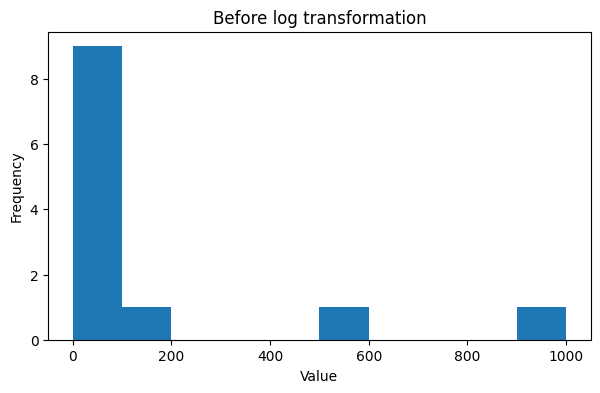

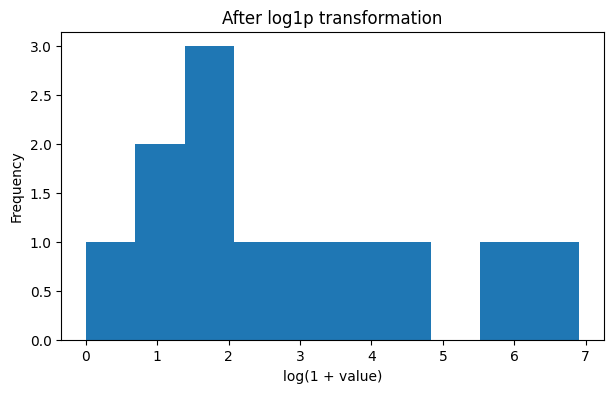

In [34]:
skewed_values = pd.Series(
    [0, 1, 2, 3, 4, 5, 10, 20, 50, 100, 500, 1000],
    name="raw"
)

transformed = np.log1p(skewed_values)

print("Skewness before:", skewed_values.skew())
print("Skewness after :", transformed.skew())

fig = plt.figure(figsize=(7, 4))
plt.hist(skewed_values)
plt.title("Before log transformation")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

fig = plt.figure(figsize=(7, 4))
plt.hist(transformed)
plt.title("After log1p transformation")
plt.xlabel("log(1 + value)")
plt.ylabel("Frequency")
plt.show()

# 6. Capstone Challenge

This final dataset combines several common problems.

**Goal:** create an analysis-ready table and explain your decisions.

In [35]:
customers_raw = pd.DataFrame({
    "customer_id": [101,102,103,104,105,106,107,108,108],
    "region": ["North","north","SOUTH","South","East","E","West",None,None],
    "age": [25, np.nan, 42, -3, 31, 67, 38, 29, 29],
    "income": [52000, 61000, np.nan, 48000, 73000, 120000, 58000, 66000, 66000],
    "monthly_spend": [240, 310, 180, 220, -50, 540, 275, np.nan, np.nan],
    "plan": ["Basic","basic","Pro","PRO","Premium","premium","Basic","Pro","Pro"]
})

display(customers_raw)

,customer_id,region,age,income,monthly_spend,plan
0,101,North,25.0,52000.0,240.0,Basic
1,102,north,NaN,61000.0,310.0,basic
2,103,SOUTH,42.0,NaN,180.0,Pro
3,104,South,-3.0,48000.0,220.0,PRO
4,105,East,31.0,73000.0,-50.0,Premium
5,106,E,67.0,120000.0,540.0,premium
6,107,West,38.0,58000.0,275.0,Basic
7,108,None,29.0,66000.0,NaN,Pro
8,108,None,29.0,66000.0,NaN,Pro


### Capstone tasks

Create `customers_clean` and do the following:

1. Remove duplicate `customer_id` rows.
2. Standardize `region` to `North`, `South`, `East`, `West`.
3. Standardize `plan` to `Basic`, `Pro`, `Premium`.
4. Treat negative `age` and negative `monthly_spend` as invalid and replace them with missing values.
5. Fill missing `age`, `income`, and `monthly_spend` with their medians.
6. Fill missing `region` with the mode.
7. One-hot encode `region` and `plan`.
8. Standardize `age`, `income`, and `monthly_spend` using `StandardScaler`.
9. Display the final table.
10. In 2–3 sentences, explain one preprocessing decision that could reasonably be made differently in a real project.

In [38]:
# TODO: complete the capstone here.
# Start with:
customers_clean = customers_raw.copy()

# 1.
customers_clean.drop_duplicates(subset="customer_id", keep="first", inplace=True)

# 2.
customers_clean["region"] = customers_clean["region"].str.capitalize()

# 3.
customers_clean["plan"] = customers_clean["plan"].str.capitalize()

# 4.
customers_clean.loc[customers_clean["age"] < 0, "age"] = np.nan
customers_clean.loc[customers_clean["monthly_spend"] < 0, "monthly_spend"] = np.nan

# 5.
customers_clean["age"].fillna(customers_clean["age"].median(), inplace=True)
customers_clean["income"].fillna(customers_clean["income"].median(), inplace=True)
customers_clean["monthly_spend"].fillna(customers_clean["monthly_spend"].median(), inplace=True)

# 6.
customers_clean["region"].fillna(customers_clean["region"].mode()[0], inplace=True)

# 7.
customers_clean = pd.get_dummies(customers_clean, columns=["region", "plan"])

# 8.
scaler = StandardScaler()
customers_clean[["age", "income", "monthly_spend"]] = scaler.fit_transform(customers_clean[["age", "income", "monthly_spend"]])

# 9.
display(customers_clean)


/tmp/ipykernel_843/4111452390.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers_clean["age"].fillna(customers_clean["age"].median(), inplace=True)
/tmp/ipykernel_843/4111452390.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

,customer_id,age,income,monthly_spend,region_E,region_East,region_North,region_South,region_West,plan_Basic,plan_Premium,plan_Pro
0,101,-1.039801,-0.726413,-0.437757,False,False,True,False,False,True,False,False
1,102,-0.257377,-0.301196,0.243198,False,False,True,False,False,True,False,False
2,103,0.360327,-0.301196,-1.021432,False,False,False,True,False,False,False,True
3,104,-0.257377,-0.915399,-0.632315,False,False,False,True,False,False,False,True
4,105,-0.545638,0.265761,-0.267518,False,True,False,False,False,False,True,False
5,106,2.419340,2.486341,2.480621,True,False,False,False,False,False,True,False
6,107,0.030885,-0.442935,-0.097279,False,False,False,False,True,True,False,False
7,108,-0.710359,-0.064964,-0.267518,False,False,True,False,False,False,False,True


**Your explanation of one decision that could be made differently:**

In a real project where a monthly spending doesn't change frequently, you could use forward fill instead of the median. Forward fill could be more accurate if the value changes gradualy over time, and it only slightly varies per month.

# 7. Exit Ticket

Answer these without running more code.

1. What is the difference between **data integration** and **data cleaning**?
Data integrations combines sources, data cleaning ensures there is no bad data in the sources.
2. When would a **left join** be safer than an inner join?
Inner joins could get rid of a significant portion of the data. Unlike left join which would keep everything from the left df.
3. Why should you check row counts immediately after a join?
To prevent row inflation.
4. Give one reason that deleting all rows with missing values can be harmful.
Deleting all missing values can introduce sample bias.
5. What is the difference between **sampling** and **PCA** as data-reduction strategies?
Sampling reduces the # of rows, while PCA reduces the # of columns.
6. Why can one-hot encoding be better than assigning arbitrary integers to unordered categories?
Arbitrary integers introduce a false numerical order that can confuse ML algorithms.
7. What is one key difference between min-max scaling and z-score standardization?
Min-max scaling scores values on a scale of 0 to 1. Z-score standardization scores values around 0.
8. What does 'garbage in, garbage out' mean in a data-analysis project?
Ensure that you have good data to start with. If the data is flawed or dirty, it will give useless results.

# 8. Optional extension exercises

If you finish early:

1. Replace median imputation in the capstone with mean imputation. Compare the final values.
2. Use `RobustScaler` from scikit-learn and compare it with `StandardScaler`.
3. Run PCA with enough components to preserve at least 90% of the Wine dataset variance.
4. Try a `right` join on the passenger tables and explain the result in one sentence.
5. Find the two Wine features with the strongest *negative* correlation.
6. Create a validation rule that flags ages outside a range you choose and explain your choice.

---
## Key message

**Good preprocessing is not about changing as much data as possible. It is about making justified changes that make the data more reliable and appropriate for the analysis.**